# Separator & Gas Scrubber Separation Efficiency

This notebook demonstrates the **separation-efficiency report** for a
**two-phase gas scrubber** and a **three-phase separator** in NeqSim.

`SeparatorMechanicalDesign.calculateSeparationEfficiency()` returns a
`SeparatorEfficiencyReport` that combines:

1. **Physics-based entrainment / carry-under** (droplet size distributions + grade
   efficiency curves + the internals database), and
2. a per-internal **Souders-Brown K-factor operating window** — is the mist mat /
   vane pack / cyclone *below turndown*, *in range*, or *flooding*?

The K-factor window comes from `resources/designdata/SeparatorInternals.csv`
(`MinKFactor_m_s` / `MaxKFactor_m_s`, open literature).

The report is **read-only** — it does not change what `run()` does. Applying the
physics model at run time is a separate opt-in switch
(`setEfficiencyModelEnabled(true/false)`); the default keeps the legacy behaviour
of *no entrainment* or *manually specified* `setEntrainment(...)`.


In [1]:
# --- NeqSim workspace setup (loads Java classes from target/classes) ---
import os
import sys
from pathlib import Path


def find_neqsim_project_root():
    env_root = os.environ.get("NEQSIM_PROJECT_ROOT")
    candidates = []
    if env_root:
        candidates.append(Path(env_root).resolve())
    here = Path.cwd().resolve()
    candidates.extend([here] + list(here.parents))
    for c in candidates:
        if (c / "pom.xml").exists() and (c / "devtools" / "neqsim_dev_setup.py").exists():
            return c
    raise RuntimeError("Could not find NeqSim project root. Set NEQSIM_PROJECT_ROOT.")


PROJECT_ROOT = find_neqsim_project_root()
sys.path.insert(0, str(PROJECT_ROOT / "devtools"))

from neqsim_dev_setup import neqsim_init, neqsim_classes

ns = neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=True)
ns = neqsim_classes(ns)
print("NeqSim classes loaded from", PROJECT_ROOT / "target" / "classes")


NeqSim project root: C:\Users\ESOL\Documents\GitHub\neqsim
Classpath:
  1. C:\Users\ESOL\Documents\GitHub\neqsim\target\classes
  2. C:\Users\ESOL\Documents\GitHub\neqsim\src\main\resources
  3. C:\Users\ESOL\.m2\repository\com\h2database\h2\2.4.240\h2-2.4.240.jar
  4. C:\Users\ESOL\.m2\repository\org\apache\logging\log4j\log4j-api\2.26.1\log4j-api-2.26.1.jar
  5. C:\Users\ESOL\.m2\repository\org\apache\logging\log4j\log4j-core\2.26.1\log4j-core-2.26.1.jar
  6. C:\Users\ESOL\.m2\repository\com\thoughtworks\xstream\xstream\1.4.21\xstream-1.4.21.jar
  7. C:\Users\ESOL\.m2\repository\io\github\x-stream\mxparser\1.2.2\mxparser-1.2.2.jar
  8. C:\Users\ESOL\.m2\repository\xmlpull\xmlpull\1.1.3.1\xmlpull-1.1.3.1.jar
  9. C:\Users\ESOL\.m2\repository\org\apache\commons\commons-lang3\3.20.0\commons-lang3-3.20.0.jar
  10. C:\Users\ESOL\.m2\repository\org\apache\commons\commons-math3\3.6.1\commons-math3-3.6.1.jar
  11. C:\Users\ESOL\.m2\repository\org\ejml\ejml-all\0.46.0\ejml-all-0.46.0.jar
  12


JVM started: C:\Users\ESOL\graalvm\graalvm-jdk-25.0.1+8.1\bin\server\jvm.dll
Ready — call neqsim_classes(ns) to import classes


All NeqSim classes imported OK
NeqSim classes loaded from C:\Users\ESOL\Documents\GitHub\neqsim\target\classes


In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt

GasScrubber = ns.JClass("neqsim.process.equipment.separator.GasScrubber")


def report_to_dict(report):
    """Parse a SeparatorEfficiencyReport into a Python dict."""
    return json.loads(str(report.toJson()))


def print_windows(rep):
    for w in rep["internals"]:
        print("  %-18s %-20s K=%.3f in [%.3f, %.3f]  util=%.2f" % (
            w["name"], w["status"], w["operatingKFactor_m_s"],
            w["minKFactor_m_s"], w["maxKFactor_m_s"], w["utilization"]))


## Part 1 — Two-phase gas scrubber

A wet gas (methane with a little condensate) enters a vertical `GasScrubber`. We
size it, fit a standard wire-mesh mist mat, and assess its efficiency and K-factor
window.


In [3]:
fluid = ns.SystemSrkEos(273.15 + 25.0, 60.0)
fluid.addComponent("methane", 0.92)
fluid.addComponent("propane", 0.03)
fluid.addComponent("n-heptane", 0.05)
fluid.setMixingRule("classic")

feed = ns.Stream("wet gas", fluid)
feed.setFlowRate(45000.0, "kg/hr")
feed.setTemperature(25.0, "C")
feed.setPressure(60.0, "bara")
feed.run()

scrubber = GasScrubber("inlet scrubber", feed)
scrubber.run()

design = scrubber.getMechanicalDesign()
design.calcDesign()
design.setDesign()                      # push the sized diameter to the scrubber

design.setDemisterType("wire_mesh")
design.setDemisterSubType("Standard Knitted")

report = design.calculateSeparationEfficiency()
rep = report_to_dict(report)

print("Scrubber inner diameter : %.3f m" % design.getInnerDiameter())
print("Operating K-factor      : %.3f m/s" % rep["operatingKFactor_m_s"])
print("Gas-liquid efficiency   : %.4f" % rep["overallGasLiquidEfficiency"])
print("Mist eliminator flooded : %s" % rep["mistEliminatorFlooded"])
print("Verdict                 : %s" % rep["verdict"])
print("K-factor windows:")
print_windows(rep)


Scrubber inner diameter : 0.855 m
Operating K-factor      : 0.100 m/s
Gas-liquid efficiency   : 0.9947
Mist eliminator flooded : False
Verdict                 : GOOD_PERFORMANCE
K-factor windows:
  mist eliminator    IN_RANGE             K=0.100 in [0.020, 0.107]  util=0.93


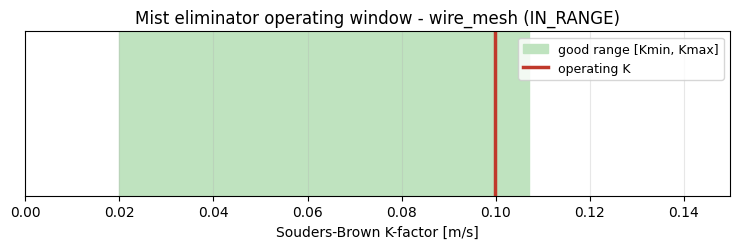

In [4]:
w = rep["internals"][0]
fig, ax = plt.subplots(figsize=(7.5, 2.6))
ax.axvspan(w["minKFactor_m_s"], w["maxKFactor_m_s"], color="#bfe3bf",
           label="good range [Kmin, Kmax]")
ax.axvline(w["operatingKFactor_m_s"], color="#c0392b", lw=2.5, label="operating K")
ax.set_xlim(0, max(w["maxKFactor_m_s"] * 1.4, w["operatingKFactor_m_s"] * 1.2))
ax.set_yticks([])
ax.set_xlabel("Souders-Brown K-factor [m/s]")
ax.set_title("Mist eliminator operating window - %s (%s)" % (w["type"], w["status"]))
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


**Interpretation.** If the operating K sits inside the green band, the mist mat is
in its good performance range. Near / above `Kmax` the mat starts to flood and
re-entrain captured liquid; well below `Kmin` the gas load is too low for effective
inertial capture (turndown limit).

## Part 2 — Three-phase separator (gas / oil / water)

A well fluid with gas, condensate and water enters a `ThreePhaseSeparator`. We first
produce the **read-only** report (efficiency model OFF, so `run()` is unchanged),
then **turn the physics model on** so `run()` applies the computed carry-over.


In [5]:
f3 = ns.SystemSrkCPAstatoil(273.15 + 45.0, 50.0)
f3.addComponent("methane", 0.70)
f3.addComponent("propane", 0.05)
f3.addComponent("nC10", 0.15)
f3.addComponent("water", 0.10)
f3.setMixingRule(10)
f3.setMultiPhaseCheck(True)

feed3 = ns.Stream("well fluid", f3)
feed3.setFlowRate(90000.0, "kg/hr")
feed3.setTemperature(45.0, "C")
feed3.setPressure(50.0, "bara")
feed3.run()

sep3 = ns.ThreePhaseSeparator("1st stage separator", feed3)
sep3.run()

d3 = sep3.getMechanicalDesign()
d3.calcDesign()
d3.setDesign()
d3.setDemisterType("vane_pack")         # vane pack: wider K window than wire mesh

# 1) Read-only assessment (efficiency model OFF by default -> run() unchanged)
print("Efficiency model enabled (default):", bool(d3.isEfficiencyModelEnabled()))
rep3 = report_to_dict(d3.calculateSeparationEfficiency())
print("three-phase :", rep3["threePhase"], "| verdict:", rep3["verdict"])
print("operating K : %.3f m/s | gas-liquid eff: %.4f" % (
    rep3["operatingKFactor_m_s"], rep3["overallGasLiquidEfficiency"]))
print_windows(rep3)

# 2) Turn the physics model ON so run() applies computed entrainment / carry-under
d3.setEfficiencyModelEnabled(True)
sep3.run()
print("\nEfficiency model enabled now       :", bool(d3.isEfficiencyModelEnabled()))
print("Separator detailed entrainment on   :", bool(sep3.isDetailedEntrainmentCalculation()))

rep3b = report_to_dict(d3.calculateSeparationEfficiency())
print("\nEntrainment / carry-under fractions (three-phase):")
for k, v in rep3b["entrainment"].items():
    print("  %-20s %.3e" % (k, v))


Efficiency model enabled (default): False
three-phase : True | verdict: MARGINAL_EFFICIENCY
operating K : 0.110 m/s | gas-liquid eff: 0.9865
  mist eliminator    IN_RANGE             K=0.110 in [0.020, 0.150]  util=0.73

Efficiency model enabled now       : True
Separator detailed entrainment on   : True

Entrainment / carry-under fractions (three-phase):
  oilInGasFraction     1.353e-02
  waterInGasFraction   1.353e-02
  gasInOilFraction     3.000e-01
  gasInWaterFraction   3.000e-01
  oilInWaterFraction   1.702e-02
  waterInOilFraction   1.298e-02


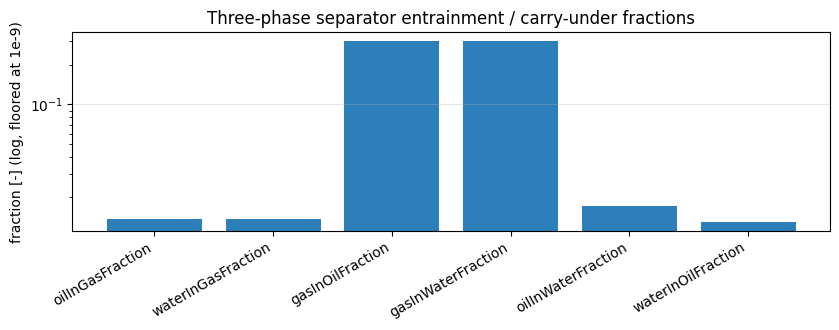

In [6]:
ent = rep3b["entrainment"]
labels = list(ent.keys())
vals = [max(float(ent[k]), 1e-9) for k in labels]  # floor for log axis

fig, ax = plt.subplots(figsize=(8.5, 3.4))
ax.bar(labels, vals, color="#2c7fb8")
ax.set_yscale("log")
ax.set_ylabel("fraction [-] (log, floored at 1e-9)")
ax.set_title("Three-phase separator entrainment / carry-under fractions")
plt.xticks(rotation=30, ha="right")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


The three-phase report additionally carries the **liquid-liquid** fractions
`oilInWaterFraction` (oil in produced water) and `waterInOilFraction` (BS&W in
oil), computed from oil/water droplet settling in the vessel.

## Part 3 — Turndown: operating K vs feed rate

Keeping the **sized vessel diameter fixed**, we sweep the gas feed rate. As flow
drops the operating K falls through the mist-eliminator window — this is exactly the
"good performance range" concept: too little flow → below turndown, too much →
flooding.


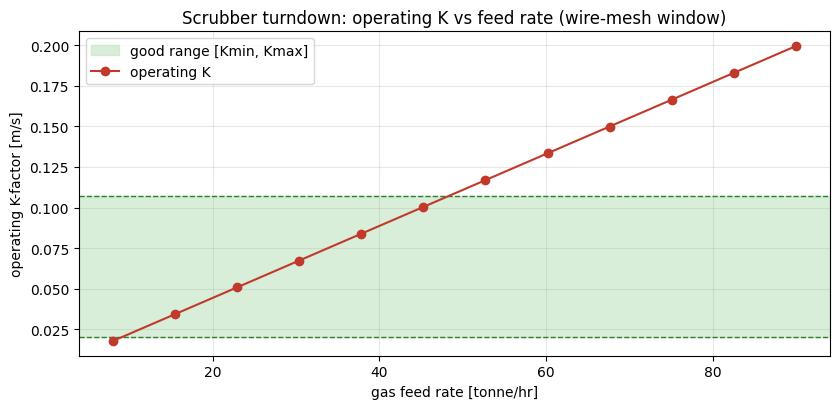

In [7]:
# Vessel is already sized (Part 1). Keep the diameter fixed and vary flow.
flows = np.linspace(8000.0, 90000.0, 12)  # kg/hr
kops = []
for fr in flows:
    feed.setFlowRate(float(fr), "kg/hr")
    feed.run()
    scrubber.run()
    r = report_to_dict(design.calculateSeparationEfficiency())  # no re-sizing
    kops.append(r["operatingKFactor_m_s"])

# restore design flow
feed.setFlowRate(45000.0, "kg/hr")
feed.run()
scrubber.run()

w0 = rep["internals"][0]
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.axhspan(w0["minKFactor_m_s"], w0["maxKFactor_m_s"], color="#bfe3bf", alpha=0.6,
           label="good range [Kmin, Kmax]")
ax.axhline(w0["minKFactor_m_s"], color="#2e7d32", ls="--", lw=1)
ax.axhline(w0["maxKFactor_m_s"], color="#2e7d32", ls="--", lw=1)
ax.plot(flows / 1000.0, kops, "o-", color="#c0392b", label="operating K")
ax.set_xlabel("gas feed rate [tonne/hr]")
ax.set_ylabel("operating K-factor [m/s]")
ax.set_title("Scrubber turndown: operating K vs feed rate (wire-mesh window)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Summary

- `calculateSeparationEfficiency()` gives a **whole-separator / scrubber**
  efficiency assessment for **two-phase and three-phase** vessels, driven by how the
  internals are configured and by the internals **database** K-factor windows.
- Each internal is classified `BELOW_MIN_TURNDOWN` / `IN_RANGE` /
  `ABOVE_MAX_FLOODING`; the report rolls this up to a verdict
  (`GOOD_PERFORMANCE`, `BELOW_TURNDOWN`, `FLOODING_RISK`, `MARGINAL_EFFICIENCY`).
- The physics entrainment / carry-under model is **opt-in** via
  `setEfficiencyModelEnabled(true)`; the default preserves *no entrainment* or
  *manual* `setEntrainment(...)`.
- Choose the internal with `setDemisterType(...)` and `setDemisterSubType(...)`.

See `docs/process/equipment/separators.md` (Separation Efficiency Report) and
`docs/process/equipment/separator-entrainment-modeling.md`.
